##CONFIGURE ENVIRONMENT VARIABLES

In [ ]:
import requests
from google.cloud import storage
from google.colab import auth
from tqdm.auto import tqdm
import os
from google.colab import userdata
import json

# --- 1. Securely get the key from Colab Secrets ---
key_string = userdata.get('GCP_KEY')
key_data = json.loads(key_string)

# --- 2. Authenticate gsutil ---
with open('temp_key.json', 'w') as f:
    json.dump(key_data, f)

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = 'temp_key.json'
!gcloud auth activate-service-account --key-file=temp_key.json

# --- 2. Configuration Variables ---
BUCKET_NAME = "asvspoof-la-data-bucket"

# The file to download (ASVspoof 5 Eval Shard 'aa')
DOWNLOAD_URL = "https://zenodo.org/records/14498691/files/flac_E_aa.tar?download=1"

# Where to save it in your bucket
DESTINATION_BLOB_NAME = "ASVspoof5/flac_E_aa.tar"

Activated service account credentials for: [colab-storage-reader@voiceauth-479800.iam.gserviceaccount.com]


##CONFIGURE FILE PATHS

In [ ]:
import os
import tarfile
import pandas as pd
import tensorflow as tf
import numpy as np
from tqdm.auto import tqdm

# --- Configuration ---
# 1. Path to the tar file you just downloaded (Local or GCS)
GCS_TAR_PATH = f"gs://{BUCKET_NAME}/ASVspoof5/flac_E_ae.tar"
LOCAL_TAR_PATH = "/content/flac_E_ae.tar"

# 2. Where to extract the audio files
EXTRACT_PATH = "/content/flac_E_eval"

# 3. Path to the Protocol File (Labels)
PROTOCOL_PATH = f"gs://{BUCKET_NAME}/ASVspoof5/protocols/ASVspoof5.eval.track_1.tsv"

print("✅ Configuration set.")

✅ Configuration set.


##EXTRACT AUDIO FILES FROM GOOGLE CLOUD SERVICES BUCKET

In [ ]:
# --- Extract Audio Files ---

# 1. Check if we need to copy from GCS
if not os.path.exists(LOCAL_TAR_PATH):
    print(f"Copying {GCS_TAR_PATH} to local disk...")
    !gsutil cp {GCS_TAR_PATH} {LOCAL_TAR_PATH}

# 2. Extract the files
if not os.path.exists(EXTRACT_PATH):
    print(f"Extracting {LOCAL_TAR_PATH}...")
    with tarfile.open(LOCAL_TAR_PATH) as tar:
        tar.extractall(path="/content")
    print("✅ Extraction complete.")
else:
    print("✅ Files already extracted.")

# 3. Verify extraction
extracted_files = os.listdir(EXTRACT_PATH)
print(f"Found {len(extracted_files)} files in {EXTRACT_PATH}")
print(f"Example file: {extracted_files[0]}")

Copying gs://asvspoof-la-data-bucket/ASVspoof5/flac_E_ae.tar to local disk...
Copying gs://asvspoof-la-data-bucket/ASVspoof5/flac_E_ae.tar...
==> NOTE: You are downloading one or more large file(s), which would
run significantly faster if you enabled sliced object downloads. This
feature is enabled by default but requires that compiled crcmod be
installed (see "gsutil help crcmod").

\ [1 files][  7.9 GiB/  7.9 GiB]   76.2 MiB/s                                   
Operation completed over 1 objects/7.9 GiB.                                      
Extracting /content/flac_E_ae.tar...


/tmp/ipython-input-1070124683.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="/content")


✅ Extraction complete.
Found 68188 files in /content/flac_E_eval
Example file: E_0004440834.flac


##LOAD PATHS TO FILES AND LABELS

In [ ]:
import pandas as pd
import os

# --- Configuration ---
EXTRACT_PATH = "/content/flac_E_eval"
PROTOCOL_PATH = f"gs://{BUCKET_NAME}/ASVspoof5/protocols/ASVspoof5.eval.track_1.tsv"

print("Loading protocol...")

column_names = [
    'SPEAKER_ID', 'AUDIO_FILE_NAME', 'SPEAKER_GENDER', 'CODEC',
    'CODEC_Q', 'CODEC_SEED', 'ATTACK_TAG', 'ATTACK_LABEL', 'KEY', 'TMP'
]

# 1. Load Protocol
df = pd.read_csv(
    PROTOCOL_PATH,
    sep=' ',
    names=column_names,
    storage_options={'token': 'temp_key.json'}
)

# 2. Identify available files
extracted_files = os.listdir(EXTRACT_PATH)
available_files_set = set([f.replace('.flac', '') for f in extracted_files])

# 3. Filter Protocol to match available files
test_df = df[df['AUDIO_FILE_NAME'].isin(available_files_set)].copy()

test_df['LABEL'] = test_df['KEY'].apply(lambda x: 1 if x == 'spoof' else 0)

print(f"✅ Protocol Loaded.")
print(f"   Total files to test: {len(test_df)}")
print(f"   Breakdown: {test_df['KEY'].value_counts().to_dict()}")

Loading protocol...
✅ Protocol Loaded.
   Total files to test: 68188
   Breakdown: {'spoof': 54194, 'bonafide': 13994}


##FUNCTIONS FOR AUDIO AND SPECTROGRAM LOADING

In [ ]:
import soundfile as sf
import tensorflow as tf
import numpy as np

# --- Constants ---
N_MELS = 128
FRAME_LENGTH = 1024
FRAME_STEP = 512
SAMPLE_RATE = 16000

def load_audio_py(file_path_str):
    audio, _ = sf.read(file_path_str)
    return audio.astype(np.float32)


def create_spectrogram(audio_tensor):
    """Converts audio tensor to Log-Mel Spectrogram."""
    # 1. Handle channels: if audio is (N, 1), squeeze to (N,)
    if len(audio_tensor.shape) > 1:
        audio_tensor = tf.squeeze(audio_tensor, axis=-1)

    # 2. Compute STFT
    stfts = tf.signal.stft(
        audio_tensor,
        frame_length=FRAME_LENGTH,
        frame_step=FRAME_STEP,
        fft_length=FRAME_LENGTH
    )
    spectrograms = tf.abs(stfts)

    # 3. Create Mel Filterbank
    num_spectrogram_bins = stfts.shape[-1]
    linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
        N_MELS, num_spectrogram_bins, SAMPLE_RATE, 20, 4000
    )

    # 4. Apply Filterbank and Log
    mel_spectrograms = tf.tensordot(spectrograms, linear_to_mel_weight_matrix, 1)
    mel_spectrograms.set_shape(spectrograms.shape[:-1].concatenate(linear_to_mel_weight_matrix.shape[-1:]))

    log_mel_spectrograms = tf.math.log(mel_spectrograms + 1e-6)
    return log_mel_spectrograms

print("✅ Updated preprocessing functions (using SoundFile).")

✅ Updated preprocessing functions (using SoundFile).


##LOAD THE BEST MODEL FROM THE BUCKET

In [ ]:
BEST_MODEL_PATH = f"gs://{BUCKET_NAME}/models/best_cnn_model_eval_df.keras"
model = tf.keras.models.load_model(BEST_MODEL_PATH)
print(model)

<Sequential name=sequential_3, built=True>


##SPLIT DATASET INTO TRAIN / VAL / TEST

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Shuffle once for reproducibility
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

labels = test_df['LABEL'].values

# 70% train, 30% temp
train_df, temp_df = train_test_split(
    test_df,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

# Split temp into 15% val, 15% test
val_df, test_df_final = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['LABEL'].values,
    random_state=42
)

print("Split sizes:")
print(f"Train: {len(train_df)}")
print(f"Val:   {len(val_df)}")
print(f"Test:  {len(test_df_final)}")


Split sizes:
Train: 47731
Val:   10228
Test:  10229


## ASSIGN TRAINING LABELS AND WEIGHTS

In [ ]:
train_labels = train_df['LABEL'].values

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights_arr))
print("Class weights:", class_weights)


Class weights: {0: np.float64(2.4362494895875866), 1: np.float64(0.6291155924607882)}


## CONFIGURE THE DATA PIPELINE

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
MAX_TIME_FRAMES = 400   # adjust if you want more/less context

def preprocess(file_name, label):
    file_path = tf.strings.join([EXTRACT_PATH, "/", file_name, ".flac"])

    audio = tf.py_function(
        func=lambda x: load_audio_py(x.numpy().decode("utf-8")),
        inp=[file_path],
        Tout=tf.float32
    )

    audio.set_shape([None])

    spec = create_spectrogram(audio)

    # Pad / truncate
    spec = spec[:MAX_TIME_FRAMES, :]
    paddings = [[0, MAX_TIME_FRAMES - tf.shape(spec)[0]], [0, 0]]
    spec = tf.pad(spec, paddings)

    spec = tf.expand_dims(spec, -1)
    return spec, label



def make_dataset(df, batch_size=32, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df['AUDIO_FILE_NAME'].values, df['LABEL'].values)
    )

    if shuffle:
        ds = ds.shuffle(2048)

    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df_final)


## CONFIGURE THE CNN MODEL

In [ ]:
from tensorflow.keras import layers, models

input_shape = (MAX_TIME_FRAMES, N_MELS, 1)

model = models.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 400, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 400, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 200, 64, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 200, 64, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 200, 64, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 100, 32, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 100, 32, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 100, 32, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 50, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,209 (430.50 KB)

 Trainable params: 109,761 (428.75 KB)

 Non-trainable params: 448 (1.75 KB)

## TRAIN THE CNN MODEL

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1, mode='min'),
    ModelCheckpoint(
        f"gs://{BUCKET_NAME}/models/best_cnn_model_eval_df.keras",
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    )
]

EPOCHS = 50
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/50
1492/1492 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7016 - auc: 0.7742 - loss: 0.5541
Epoch 1: val_loss improved from inf to 0.56349, saving model to gs://asvspoof-la-data-bucket/models/best_cnn_model_eval_df.keras
1492/1492 ━━━━━━━━━━━━━━━━━━━━ 120s 76ms/step - accuracy: 0.7016 - auc: 0.7742 - loss: 0.5540 - val_accuracy: 0.7113 - val_auc: 0.9224 - val_loss: 0.5635
Epoch 2/50
1491/1492 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8434 - auc: 0.9300 - loss: 0.3395
Epoch 2: val_loss improved from 0.56349 to 0.23556, saving model to gs://asvspoof-la-data-bucket/models/best_cnn_model_eval_df.keras
1492/1492 ━━━━━━━━━━━━━━━━━━━━ 111s 74ms/step - accuracy: 0.8434 - auc: 0.9300 - loss: 0.3395 - val_accuracy: 0.9005 - val_auc: 0.9530 - val_loss: 0.2356
Epoch 3/50
1492/1492 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8655 - auc: 0.9481 - loss: 0.2927
Epoch 3: val_loss did not improve from 0.23556
1492/1492 ━━━━━━━━━━━━━━━━━━━━ 103s 69ms/step - accuracy: 0.8655 - auc: 0.

## TEST THE CNN MODEL

In [ ]:
test_loss, test_acc, test_auc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC:      {test_auc:.4f}")


320/320 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.9641 - auc: 0.9905 - loss: 0.0960
Test Accuracy: 0.9634
Test AUC:      0.9905


## PRINT METADATA OF RESULTS

320/320 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step

🏆 FINAL TEST RESULTS
Accuracy: 96.34%
Recall (Caught Spoofs): 97.55%
FPR (False Alarms):     8.34%
--------------------------------------------------
CONFUSION MATRIX:
              Pred Bonafide | Pred Spoof
Actual Bonafide | 1924          | 175       
Actual Spoof    | 199           | 7931      


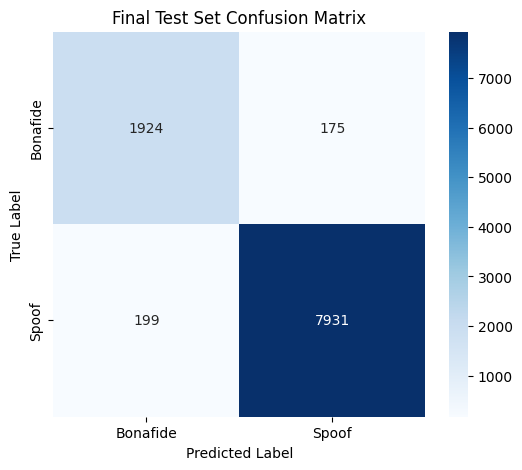


🕵️ FALSE NEGATIVE BREAKDOWN (Missed Spoofs)
Total Missed Spoofs: 199

Attack Code     | Count    | % of Failures
--------------------------------------------------
AC1             | 90       | 45.2%
AC2             | 67       | 33.7%
AC3             | 42       | 21.1%
--------------------------------------------------

📉 SPOOF MISS RATE BY ATTACK
attack
AC1    0.026331
AC3    0.024014
AC2    0.022612
Name: count, dtype: float64


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predict probabilities on test set
y_pred_probs = model.predict(test_ds).ravel()

# Convert to class labels (threshold = 0.5)
y_pred_classes = (y_pred_probs >= 0.5).astype(int)

# Ground-truth labels
y_true = test_df_final['LABEL'].values

# Attack labels
attack_labels = test_df_final['ATTACK_TAG'].values

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

# Metrics
acc = accuracy_score(y_true, y_pred_classes) * 100
recall = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0   # Spoof detection rate
fpr = fp / (fp + tn) * 100 if (fp + tn) > 0 else 0     # False alarms

print("\n" + "="*50)
print("🏆 FINAL TEST RESULTS")
print("="*50)
print(f"Accuracy: {acc:.2f}%")
print(f"Recall (Caught Spoofs): {recall:.2f}%")
print(f"FPR (False Alarms):     {fpr:.2f}%")
print("-" * 50)
print("CONFUSION MATRIX:")
print(f"              Pred Bonafide | Pred Spoof")
print(f"Actual Bonafide | {tn:<13} | {fp:<10}")
print(f"Actual Spoof    | {fn:<13} | {tp:<10}")

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Bonafide', 'Spoof'],
    yticklabels=['Bonafide', 'Spoof']
)
plt.title('Final Test Set Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

import pandas as pd

print("\n" + "="*50)
print("🕵️ FALSE NEGATIVE BREAKDOWN (Missed Spoofs)")
print("="*50)

# Create results dataframe
res_df = pd.DataFrame({
    'true': y_true,
    'pred': y_pred_classes,
    'prob': y_pred_probs,
    'attack': attack_labels
})

# Missed spoofs = Spoof (1) predicted as Bonafide (0)
fn_df = res_df[(res_df['true'] == 1) & (res_df['pred'] == 0)]

if len(fn_df) > 0:
    print(f"Total Missed Spoofs: {len(fn_df)}\n")
    print(f"{'Attack Code':<15} | {'Count':<8} | {'% of Failures'}")
    print("-" * 50)

    counts = fn_df['attack'].value_counts()
    for attack, count in counts.items():
        pct = (count / len(fn_df)) * 100
        print(f"{attack:<15} | {count:<8} | {pct:.1f}%")

    print("-" * 50)
else:
    print("🎉 PERFECT SCORE! No spoofs were missed in the test set.")

total_spoofs = (
    res_df[res_df['true'] == 1]['attack']
    .value_counts()
)

miss_rate = (counts / total_spoofs).fillna(0).sort_values(ascending=False)

print("\n📉 SPOOF MISS RATE BY ATTACK")
print(miss_rate.head(10))
